# Notebook 06 - Full Test-Set Evaluation: MobileNetV2 (Phase 1 and Phase 2)

**Project:** Image-Based Fruit Ripeness Classification  
**Student:** Corneliu Rosca | STU141830  
**Week:** 7

---

## Objective

Evaluate both transfer-learning models on the **held-out test set** (never seen during training), producing the official reference figures for the report:

1. Load each trained checkpoint and run inference on the test set.
2. Compute accuracy, per-class precision/recall/F1, and macro averages.
3. Plot the confusion matrix (count + normalised).
4. Plot one-vs-rest ROC curves with per-class and macro AUC.
5. Assemble a three-model comparison (Baseline vs Phase 1 vs Phase 2) on the test set.

## Note on class ordering

The MobileNetV2 models were trained with `image_dataset_from_directory`, which orders classes **alphabetically**. Predictions and labels are permuted back to the canonical `CLASS_NAMES` order (via `src.utils`) so every figure here uses the same ordering as the Baseline figures in the report. No retraining is involved.

## Note on expected results

The test set holds 72 images (~8 per class), so a single misclassification shifts accuracy by ~1.4 pp. Test accuracy is therefore expected to sit somewhat below the validation figures, while the macro AUC (a threshold-independent ranking measure) should remain high. All logic comes from `src.evaluate`; this notebook orchestrates and presents it, with every plot rendered inline and saved to `results/`.

## 1. Setup

Import the evaluation components from `src/` and define a small helper that evaluates one model and renders its report, confusion matrix, and ROC curves inline.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import tensorflow as tf

from src.utils import (SAVED_MODELS, alpha_probs_to_canonical, alpha_labels_to_canonical)
from src.data_pipeline import build_mobilenet_test_dataset
from src.evaluate import (get_predictions, compute_metrics,
                          plot_confusion_matrix, plot_roc_curves, update_results_csv)

PROJECT_ROOT = Path.cwd().parent
RESULTS = str(PROJECT_ROOT / 'results')
SPLITS  = str(PROJECT_ROOT / 'dataset_splits')

def evaluate_model(tag):
    """Evaluate one MobileNetV2 checkpoint on the test set with inline plots."""
    print(f'\n{"="*60}\n  {tag} - test-set evaluation\n{"="*60}')
    model = tf.keras.models.load_model(
        str(PROJECT_ROOT / 'saved_models' / SAVED_MODELS[tag]), compile=False)
    test_ds, _ = build_mobilenet_test_dataset(SPLITS, batch_size=32)
    yt_a, ys_a = get_predictions(model, test_ds)
    # permute alphabetical -> canonical so all reporting shares one order
    y_scores = alpha_probs_to_canonical(ys_a)
    y_true   = alpha_labels_to_canonical(yt_a)
    y_pred   = y_scores.argmax(axis=1)
    metrics, report = compute_metrics(y_true, y_pred)
    print('\nClassification report (canonical class order):\n')
    print(report)
    plot_confusion_matrix(y_true, y_pred, tag, RESULTS, show=True)
    macro_auc = plot_roc_curves(y_true, y_scores, tag, RESULTS, show=True)
    metrics['macro_auc'] = macro_auc
    update_results_csv(metrics, tag, RESULTS)
    print(f'\nSummary  ->  accuracy {metrics["accuracy"]:.4f} | '
          f'macro F1 {metrics["f1_macro"]:.4f} | macro AUC {macro_auc:.4f}')
    return metrics


## 2. Phase 1 (frozen base) on the test set


  mobilenet_phase1 - test-set evaluation
Found 72 files belonging to 9 classes.
Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


2026-06-09 14:34:24 [INFO] evaluate: 
Classification Report:
                 precision    recall  f1-score   support

   apple_unripe     1.0000    0.8750    0.9333         8
     apple_ripe     0.6667    1.0000    0.8000         8
 apple_overripe     1.0000    0.5000    0.6667         8
  banana_unripe     0.8889    1.0000    0.9412         8
    banana_ripe     0.8571    0.7500    0.8000         8
banana_overripe     0.8750    0.8750    0.8750         8
    pear_unripe     1.0000    0.7500    0.8571         8
      pear_ripe     0.6000    0.7500    0.6667         8
  pear_overripe     0.7778    0.8750    0.8235         8

       accuracy                         0.8194        72
      macro avg     0.8517    0.8194    0.8182        72
   weighted avg     0.8517    0.8194    0.8182        72




Classification report (canonical class order):

                 precision    recall  f1-score   support

   apple_unripe     1.0000    0.8750    0.9333         8
     apple_ripe     0.6667    1.0000    0.8000         8
 apple_overripe     1.0000    0.5000    0.6667         8
  banana_unripe     0.8889    1.0000    0.9412         8
    banana_ripe     0.8571    0.7500    0.8000         8
banana_overripe     0.8750    0.8750    0.8750         8
    pear_unripe     1.0000    0.7500    0.8571         8
      pear_ripe     0.6000    0.7500    0.6667         8
  pear_overripe     0.7778    0.8750    0.8235         8

       accuracy                         0.8194        72
      macro avg     0.8517    0.8194    0.8182        72
   weighted avg     0.8517    0.8194    0.8182        72



2026-06-09 14:34:25 [INFO] evaluate: Confusion matrix saved to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results/confusion_matrix_mobilenet_phase1.png


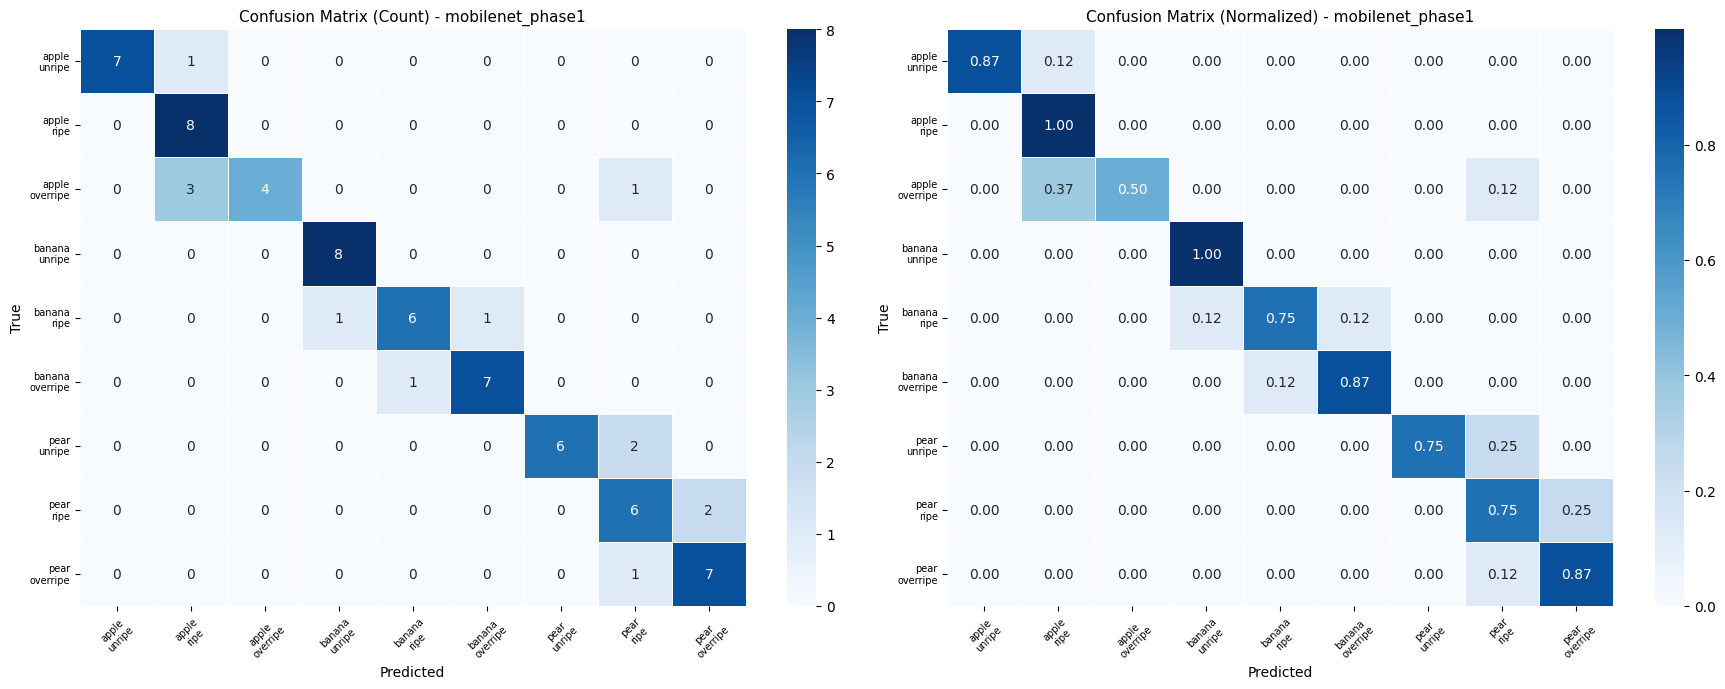

2026-06-09 14:34:25 [INFO] evaluate: ROC curves saved to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results/roc_curves_mobilenet_phase1.png (macro AUC=0.9870)


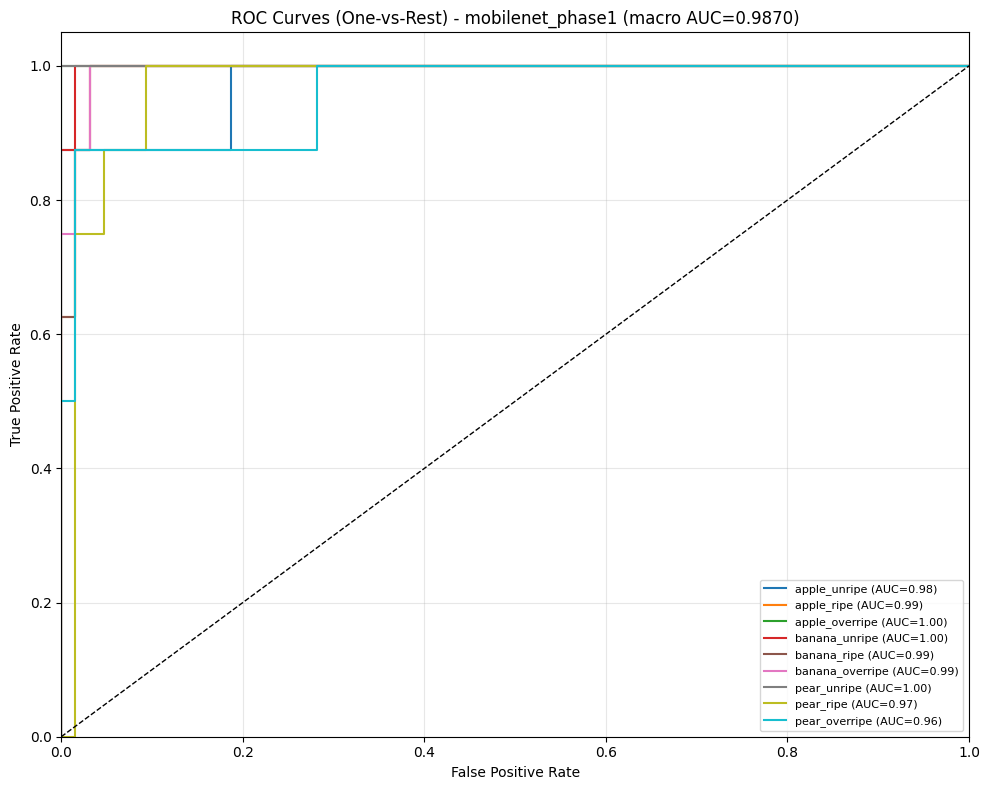

2026-06-09 14:34:26 [INFO] evaluate: Results CSV updated at d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results/results.csv



Summary  ->  accuracy 0.8194 | macro F1 0.8182 | macro AUC 0.9870


In [2]:
phase1_metrics = evaluate_model('mobilenet_phase1')


## 3. Phase 2 (fine-tuned) on the test set


  mobilenet_phase2 - test-set evaluation
Found 72 files belonging to 9 classes.


2026-06-09 14:34:28 [INFO] evaluate: 
Classification Report:
                 precision    recall  f1-score   support

   apple_unripe     1.0000    0.8750    0.9333         8
     apple_ripe     0.7273    1.0000    0.8421         8
 apple_overripe     1.0000    0.7500    0.8571         8
  banana_unripe     0.8889    1.0000    0.9412         8
    banana_ripe     0.8333    0.6250    0.7143         8
banana_overripe     0.7778    0.8750    0.8235         8
    pear_unripe     1.0000    0.8750    0.9333         8
      pear_ripe     0.7143    0.6250    0.6667         8
  pear_overripe     0.7000    0.8750    0.7778         8

       accuracy                         0.8333        72
      macro avg     0.8491    0.8333    0.8322        72
   weighted avg     0.8491    0.8333    0.8322        72




Classification report (canonical class order):

                 precision    recall  f1-score   support

   apple_unripe     1.0000    0.8750    0.9333         8
     apple_ripe     0.7273    1.0000    0.8421         8
 apple_overripe     1.0000    0.7500    0.8571         8
  banana_unripe     0.8889    1.0000    0.9412         8
    banana_ripe     0.8333    0.6250    0.7143         8
banana_overripe     0.7778    0.8750    0.8235         8
    pear_unripe     1.0000    0.8750    0.9333         8
      pear_ripe     0.7143    0.6250    0.6667         8
  pear_overripe     0.7000    0.8750    0.7778         8

       accuracy                         0.8333        72
      macro avg     0.8491    0.8333    0.8322        72
   weighted avg     0.8491    0.8333    0.8322        72



2026-06-09 14:34:29 [INFO] evaluate: Confusion matrix saved to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results/confusion_matrix_mobilenet_phase2.png


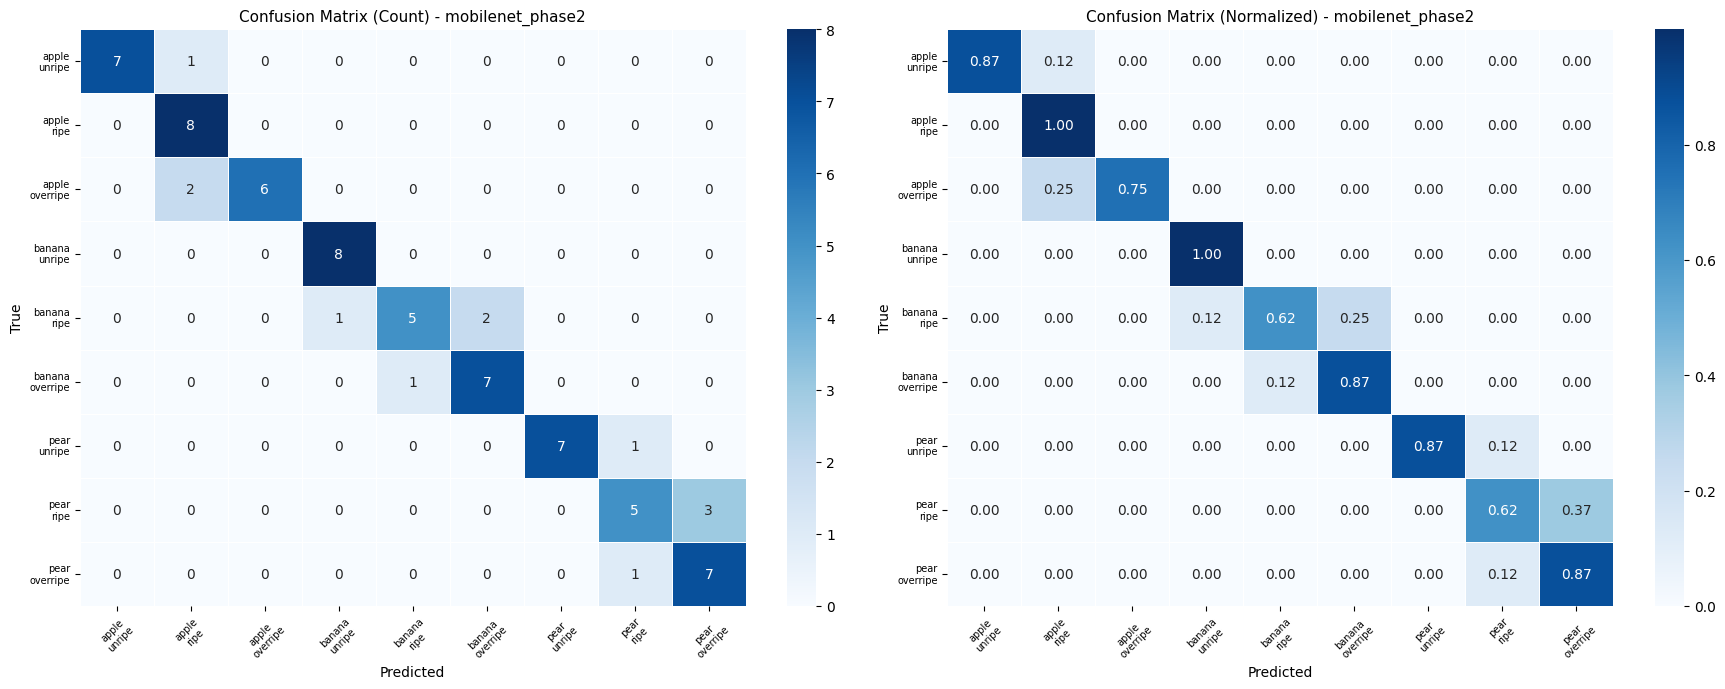

2026-06-09 14:34:30 [INFO] evaluate: ROC curves saved to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results/roc_curves_mobilenet_phase2.png (macro AUC=0.9909)


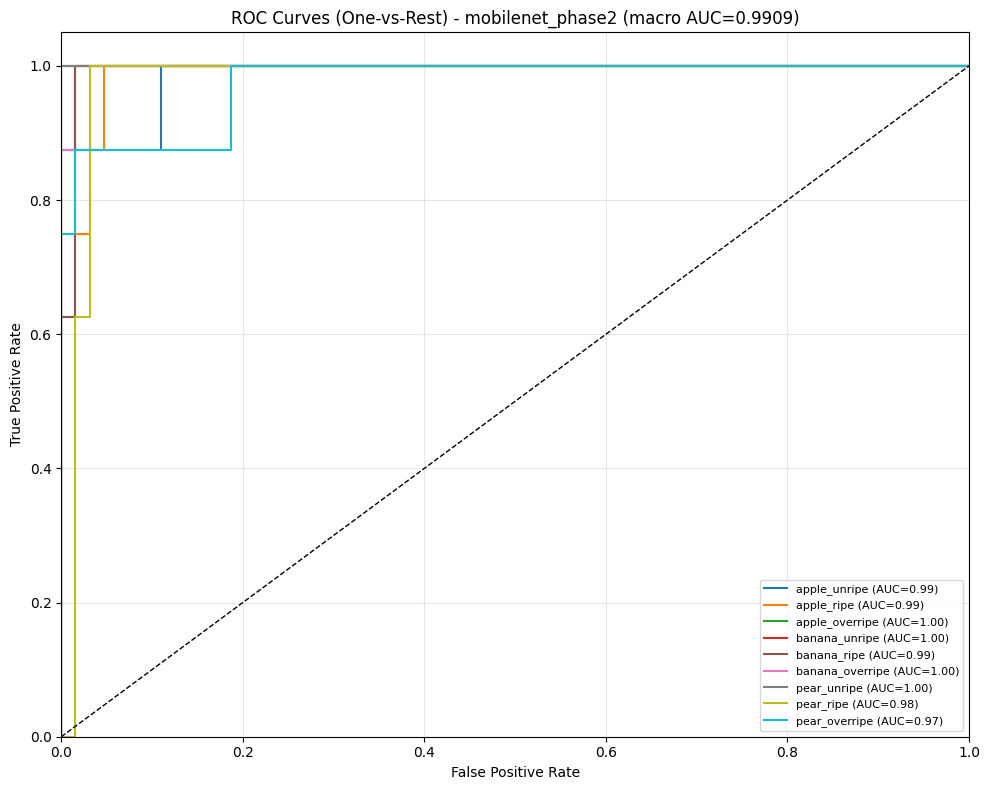

2026-06-09 14:34:30 [INFO] evaluate: Results CSV updated at d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results/results.csv



Summary  ->  accuracy 0.8333 | macro F1 0.8322 | macro AUC 0.9909


In [3]:
phase2_metrics = evaluate_model('mobilenet_phase2')


## 4. How to read these figures

- **Confusion matrix:** a strong diagonal indicates correct classification. Off-diagonal mass that concentrates on *adjacent ripeness stages of the same fruit* (for example overripe vs ripe) reflects genuine visual similarity rather than a failure to separate fruit types. Compare against the Baseline confusion matrix (Section 6.3), which showed mode collapse onto a few classes.
- **ROC / AUC:** AUC measures how well the softmax scores rank positives above negatives, independent of the decision threshold. A high macro AUC alongside a more modest accuracy means the model ranks classes well but loses some cases at the hard argmax decision, which is typical on a small test set.
- **Per-class support is 8**, so per-class precision/recall move in steps of 0.125; read them as indicative rather than precise.

## 5. Three-model comparison (test set)

Baseline test metrics are taken from the Week 4 evaluation (Section 6.3.1); Phase 1 and Phase 2 are computed above. All values are on the same held-out test set.

In [4]:
comparison = pd.DataFrame([
    {'model': 'baseline_cnn',     'test_accuracy': 0.0972, 'macro_precision': 0.0561,
     'macro_recall': 0.0972, 'macro_f1': 0.0511, 'macro_auc': 0.7212},
    {'model': 'mobilenet_phase1', 'test_accuracy': round(phase1_metrics['accuracy'], 4),
     'macro_precision': round(phase1_metrics['precision_macro'], 4),
     'macro_recall': round(phase1_metrics['recall_macro'], 4),
     'macro_f1': round(phase1_metrics['f1_macro'], 4),
     'macro_auc': round(phase1_metrics['macro_auc'], 4)},
    {'model': 'mobilenet_phase2', 'test_accuracy': round(phase2_metrics['accuracy'], 4),
     'macro_precision': round(phase2_metrics['precision_macro'], 4),
     'macro_recall': round(phase2_metrics['recall_macro'], 4),
     'macro_f1': round(phase2_metrics['f1_macro'], 4),
     'macro_auc': round(phase2_metrics['macro_auc'], 4)},
])
comparison.to_csv(PROJECT_ROOT / 'results' / 'test_evaluation_comparison.csv', index=False)
print('Three-model test-set comparison:\n')
print(comparison.to_string(index=False))
print('\nNote: baseline values reproduced from the Week 4 evaluation (Section 6.3.1).')


Three-model test-set comparison:

           model  test_accuracy  macro_precision  macro_recall  macro_f1  macro_auc
    baseline_cnn         0.0972           0.0561        0.0972    0.0511     0.7212
mobilenet_phase1         0.8194           0.8517        0.8194    0.8182     0.9870
mobilenet_phase2         0.8333           0.8491        0.8333    0.8322     0.9909

Note: baseline values reproduced from the Week 4 evaluation (Section 6.3.1).
